In [106]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


 

In [107]:
df = pd.read_csv(r"Mental Health dataset1.csv")

In [108]:
df.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,WorkInterest,SocialWeakness.1,MentalHealthInterview,CareOptions
0,Female,UK,Others,No,Yes,No,15-30 days,No,Yes,Yes,High,No,Yes,Maybe,No,No,No
1,Female,USA,Housewife,No,Yes,No,15-30 days,Maybe,Maybe,Yes,High,Maybe,Yes,Maybe,Maybe,No,Not sure
2,Female,Canada,Others,No,No,Yes,More than 2 months,Maybe,No,No,Medium,No,No,No,No,No,Not sure
3,Female,Canada,Corporate,No,Yes,Yes,Go out Every day,No,Maybe,No,Medium,No,No,Maybe,No,No,Not sure
4,Female,UK,Corporate,No,No,Yes,More than 2 months,Yes,No,Maybe,Medium,Maybe,No,Maybe,Maybe,No,Not sure


## cleaning

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 261328 entries, 0 to 261327
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   Gender                 261328 non-null  str  
 1   Country                261328 non-null  str  
 2   Occupation             261328 non-null  str  
 3   SelfEmployed           256972 non-null  str  
 4   FamilyHistory          261328 non-null  str  
 5   Treatment              261328 non-null  str  
 6   DaysIndoors            261328 non-null  str  
 7   HabitsChange           261328 non-null  str  
 8   MentalHealthHistory    261328 non-null  str  
 9   IncreasingStress       261328 non-null  str  
 10  MoodSwings             261328 non-null  str  
 11  SocialWeakness         261328 non-null  str  
 12  CopingStruggles        261328 non-null  str  
 13  WorkInterest           261328 non-null  str  
 14  SocialWeakness.1       261328 non-null  str  
 15  MentalHealthInterview  26132

In [110]:
df.isnull().sum()

Gender                      0
Country                     0
Occupation                  0
SelfEmployed             4356
FamilyHistory               0
Treatment                   0
DaysIndoors                 0
HabitsChange                0
MentalHealthHistory         0
IncreasingStress            0
MoodSwings                  0
SocialWeakness              0
CopingStruggles             0
WorkInterest                0
SocialWeakness.1            0
MentalHealthInterview       0
CareOptions                 0
dtype: int64

In [111]:
df['SelfEmployed'].value_counts(dropna=False)

SelfEmployed
No     230404
Yes     26568
NaN      4356
Name: count, dtype: int64

In [112]:
df['SelfEmployed'] = df['SelfEmployed'].fillna('No')

In [113]:
df.isnull().sum()

Gender                   0
Country                  0
Occupation               0
SelfEmployed             0
FamilyHistory            0
Treatment                0
DaysIndoors              0
HabitsChange             0
MentalHealthHistory      0
IncreasingStress         0
MoodSwings               0
SocialWeakness           0
CopingStruggles          0
WorkInterest             0
SocialWeakness.1         0
MentalHealthInterview    0
CareOptions              0
dtype: int64

In [114]:
df.duplicated().sum()

np.int64(178174)

In [115]:
df.drop_duplicates(inplace=True)

In [116]:
df.duplicated().sum()

np.int64(0)

In [117]:
df.head() 

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,WorkInterest,SocialWeakness.1,MentalHealthInterview,CareOptions
0,Female,UK,Others,No,Yes,No,15-30 days,No,Yes,Yes,High,No,Yes,Maybe,No,No,No
1,Female,USA,Housewife,No,Yes,No,15-30 days,Maybe,Maybe,Yes,High,Maybe,Yes,Maybe,Maybe,No,Not sure
2,Female,Canada,Others,No,No,Yes,More than 2 months,Maybe,No,No,Medium,No,No,No,No,No,Not sure
3,Female,Canada,Corporate,No,Yes,Yes,Go out Every day,No,Maybe,No,Medium,No,No,Maybe,No,No,Not sure
4,Female,UK,Corporate,No,No,Yes,More than 2 months,Yes,No,Maybe,Medium,Maybe,No,Maybe,Maybe,No,Not sure


In [118]:
df.shape

(83154, 17)

In [119]:
df.columns

Index(['Gender', 'Country', 'Occupation', 'SelfEmployed', 'FamilyHistory',
       'Treatment', 'DaysIndoors', 'HabitsChange', 'MentalHealthHistory',
       'IncreasingStress', 'MoodSwings', 'SocialWeakness', 'CopingStruggles',
       'WorkInterest', 'SocialWeakness.1', 'MentalHealthInterview',
       'CareOptions'],
      dtype='str')

In [120]:
df.drop('SocialWeakness.1' ,axis=1 ,inplace=True)

In [121]:
df = df.replace(['Maybe', 'Not sure'], 'Unknown')

In [122]:
df.shape

(83154, 16)

In [123]:
df.columns

Index(['Gender', 'Country', 'Occupation', 'SelfEmployed', 'FamilyHistory',
       'Treatment', 'DaysIndoors', 'HabitsChange', 'MentalHealthHistory',
       'IncreasingStress', 'MoodSwings', 'SocialWeakness', 'CopingStruggles',
       'WorkInterest', 'MentalHealthInterview', 'CareOptions'],
      dtype='str')

## EDA

In [124]:
df['Treatment'].value_counts(normalize=True) * 100

Treatment
No     52.983621
Yes    47.016379
Name: proportion, dtype: float64

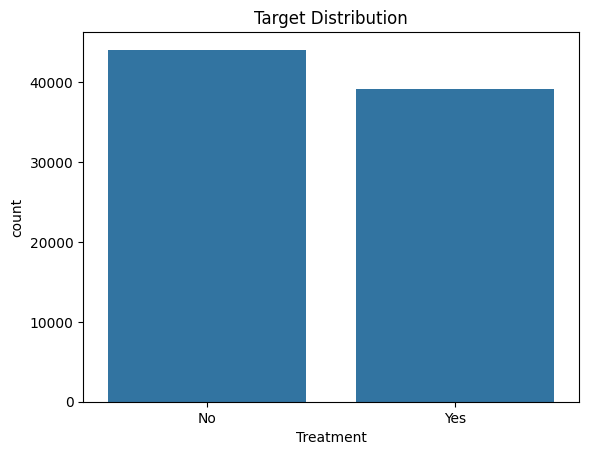

In [125]:
sns.countplot(x='Treatment', data=df)
plt.title("Target Distribution")
plt.show()

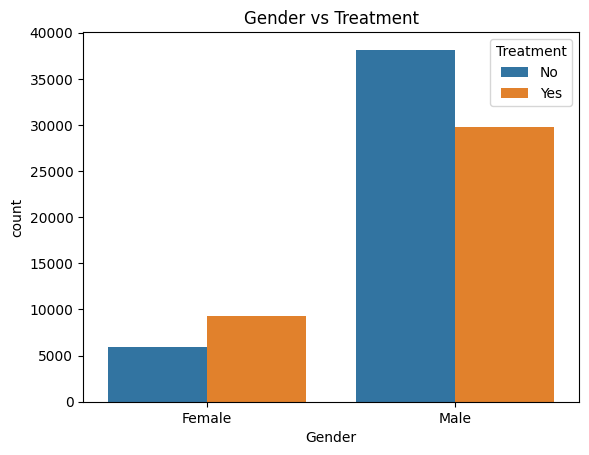

In [126]:
sns.countplot(x='Gender', hue='Treatment', data=df)
plt.title("Gender vs Treatment")
plt.show()

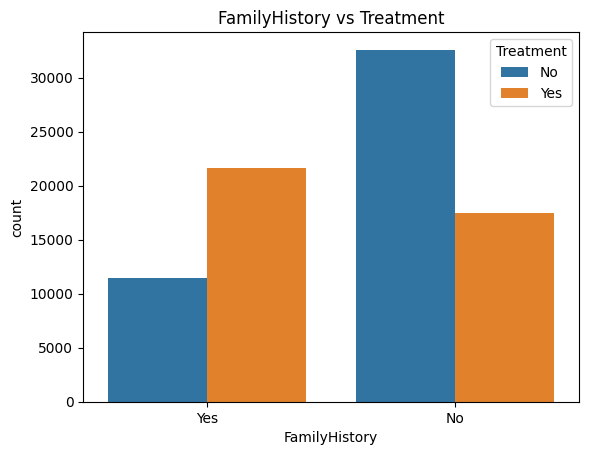

In [127]:
sns.countplot(x='FamilyHistory', hue='Treatment', data=df)
plt.title("FamilyHistory vs Treatment")
plt.show()

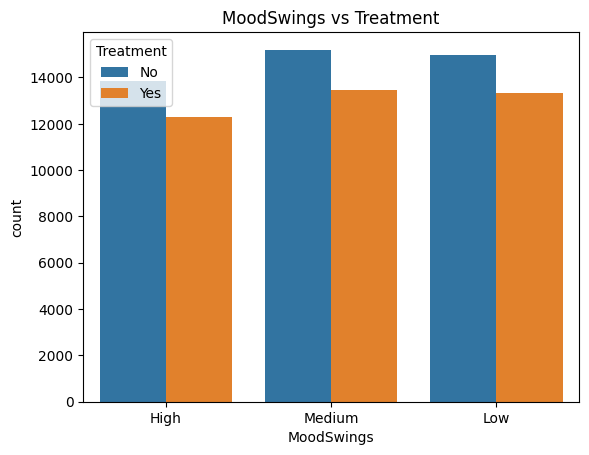

In [128]:
sns.countplot(x='MoodSwings', hue='Treatment', data=df)
plt.title("MoodSwings vs Treatment")
plt.show()

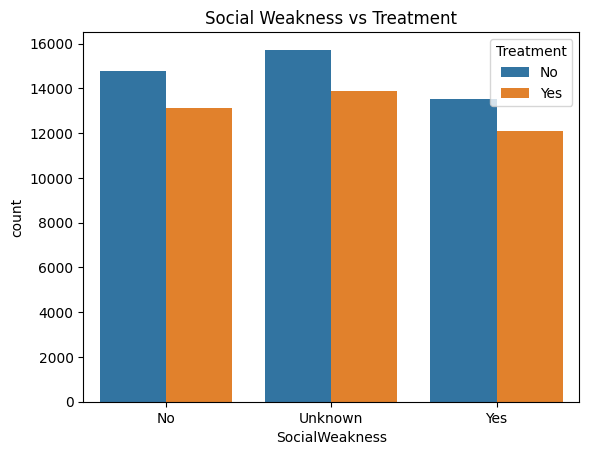

In [129]:
sns.countplot(x='SocialWeakness', hue='Treatment', data=df)
plt.title("Social Weakness vs Treatment")
plt.show()

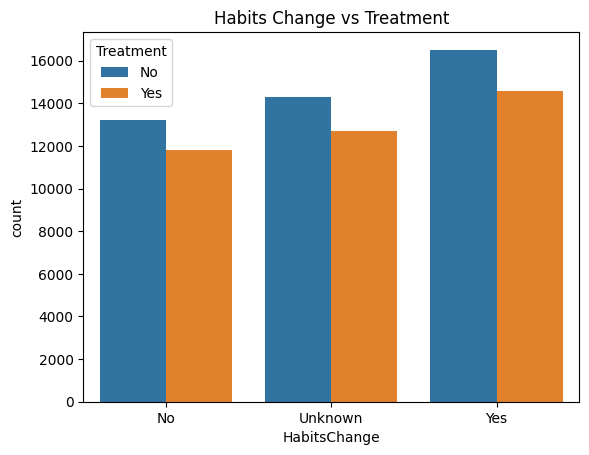

In [130]:
sns.countplot(x='HabitsChange', hue='Treatment', data=df)
plt.title("Habits Change vs Treatment")
plt.show()

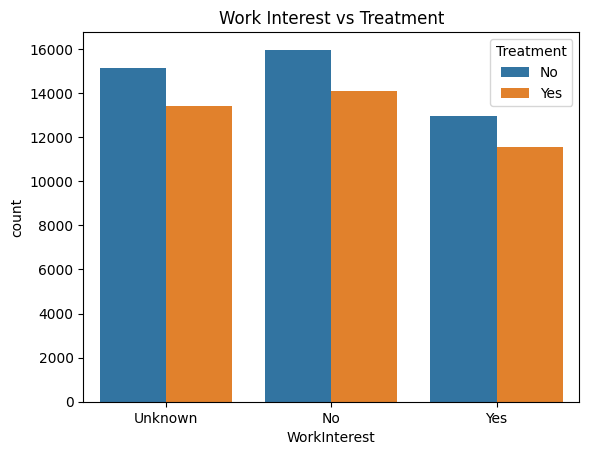

In [131]:
sns.countplot(x='WorkInterest', hue='Treatment', data=df)
plt.title("Work Interest vs Treatment")
plt.show()

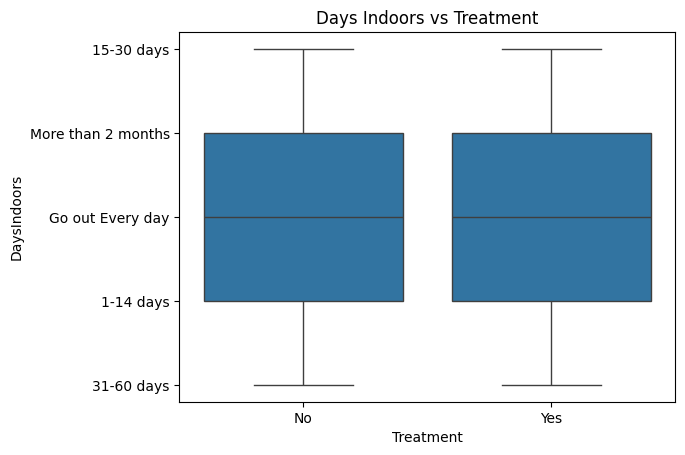

In [132]:
sns.boxplot(x='Treatment', y='DaysIndoors', data=df)
plt.title("Days Indoors vs Treatment")
plt.show()

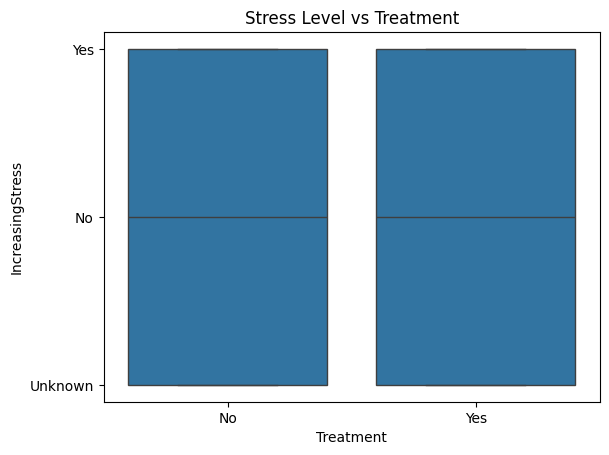

In [133]:
sns.boxplot(x='Treatment', y='IncreasingStress', data=df)
plt.title("Stress Level vs Treatment")
plt.show()

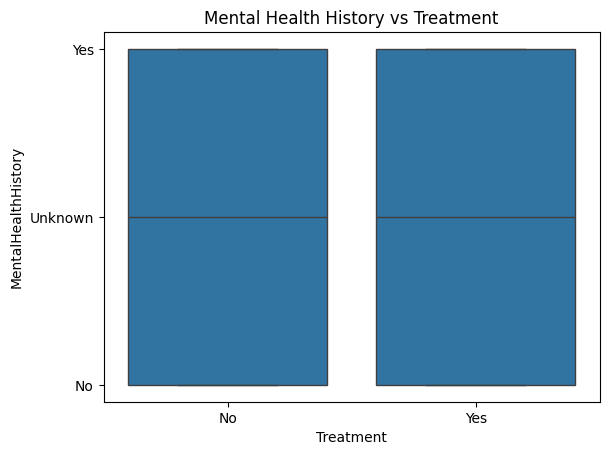

In [134]:
sns.boxplot(x='Treatment', y='MentalHealthHistory', data=df)
plt.title("Mental Health History vs Treatment")
plt.show()

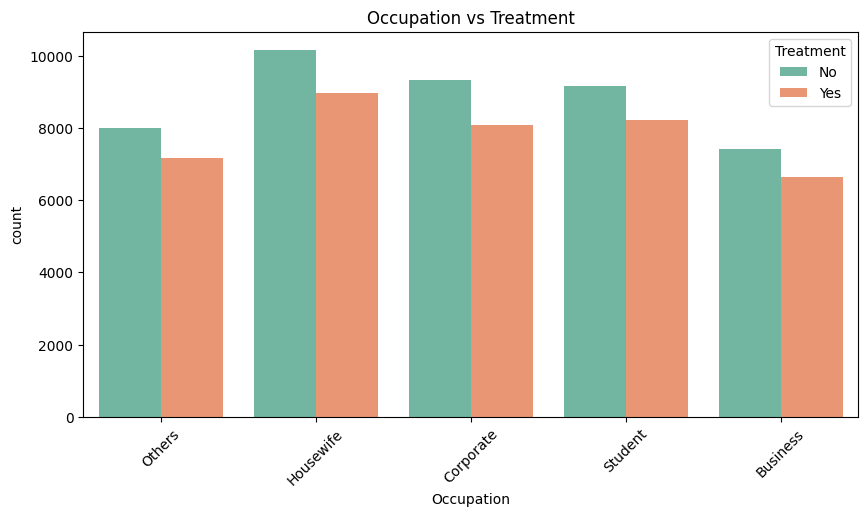

In [135]:
plt.figure(figsize=(10,5))

sns.countplot(x='Occupation', hue='Treatment', data=df, palette='Set2')

plt.title('Occupation vs Treatment')
plt.xticks(rotation=45)
plt.show()

## Encoding

In [136]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Treatment_Yes', axis=1)
y = df_encoded['Treatment_Yes']

## PCA 

In [137]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

print("Before PCA:", X.shape)
print("After PCA:", X_pca.shape)

Before PCA: (83154, 62)
After PCA: (83154, 32)


 ## TRAIN TEST SPLIT

In [138]:
# without PCA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  with PCA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

## Logistic Regression

In [139]:
log_model = LogisticRegression(max_iter=1000)


In [140]:
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("=== Logistic WITHOUT PCA ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))



=== Logistic WITHOUT PCA ===
Accuracy: 0.7021225422403945
              precision    recall  f1-score   support

       False       0.72      0.72      0.72      8860
        True       0.68      0.68      0.68      7771

    accuracy                           0.70     16631
   macro avg       0.70      0.70      0.70     16631
weighted avg       0.70      0.70      0.70     16631



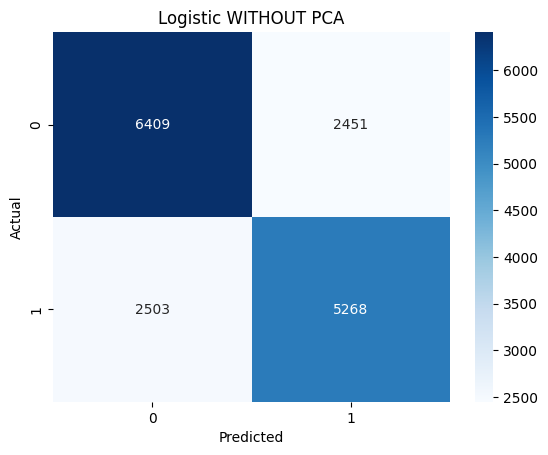

In [141]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic WITHOUT PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [142]:
log_model.fit(X_train_pca, y_train_pca)
y_pred_log_pca = log_model.predict(X_test_pca)

print("\n=== Logistic WITH PCA ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_log_pca))
print(classification_report(y_test_pca, y_pred_log_pca))


=== Logistic WITH PCA ===
Accuracy: 0.637784859599543
              precision    recall  f1-score   support

       False       0.65      0.70      0.67      8860
        True       0.62      0.57      0.59      7771

    accuracy                           0.64     16631
   macro avg       0.64      0.63      0.63     16631
weighted avg       0.64      0.64      0.64     16631



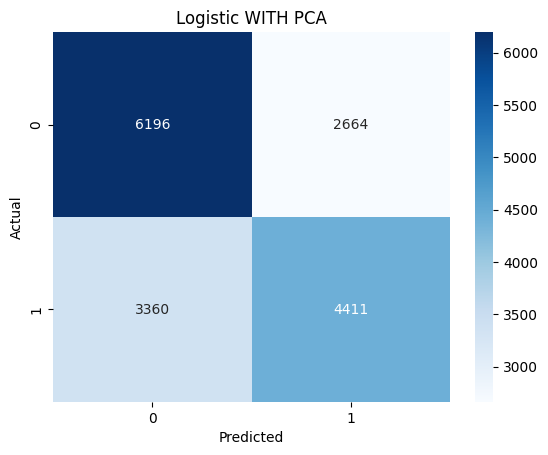

In [143]:
cm_log_pca = confusion_matrix(y_test_pca, y_pred_log_pca)

sns.heatmap(cm_log_pca, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic WITH PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [144]:
rf_model = RandomForestClassifier(n_estimators=150,
                                  max_depth=12,
                                 random_state=42)

In [145]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest WITHOUT PCA ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest WITHOUT PCA ===
Accuracy: 0.7689255005712224
              precision    recall  f1-score   support

       False       0.80      0.75      0.78      8860
        True       0.74      0.79      0.76      7771

    accuracy                           0.77     16631
   macro avg       0.77      0.77      0.77     16631
weighted avg       0.77      0.77      0.77     16631



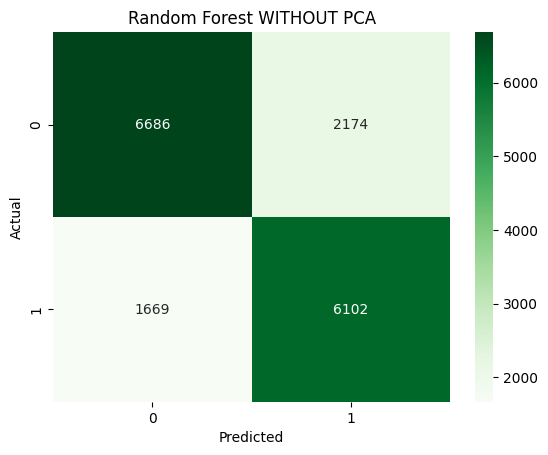

In [146]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest WITHOUT PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [147]:
rf_model.fit(X_train_pca, y_train_pca)
y_pred_rf_pca = rf_model.predict(X_test_pca)

print("\n=== Random Forest WITH PCA ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_rf_pca))
print(classification_report(y_test_pca, y_pred_rf_pca))


=== Random Forest WITH PCA ===
Accuracy: 0.720161144849979
              precision    recall  f1-score   support

       False       0.76      0.70      0.73      8860
        True       0.69      0.74      0.71      7771

    accuracy                           0.72     16631
   macro avg       0.72      0.72      0.72     16631
weighted avg       0.72      0.72      0.72     16631



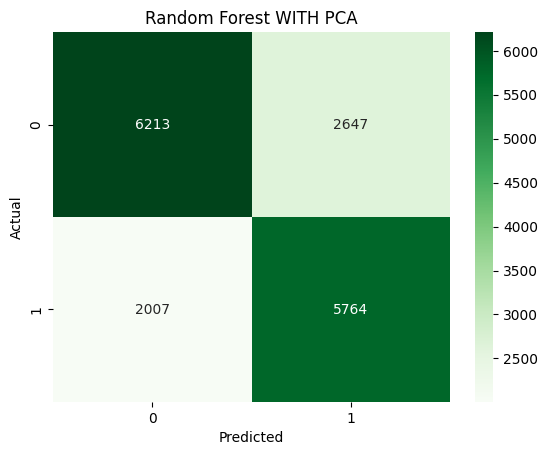

In [148]:
cm_rf_pca = confusion_matrix(y_test_pca, y_pred_rf_pca)

sns.heatmap(cm_rf_pca, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest WITH PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Hayper parameters 

In [149]:
C_values = [0.01, 0.1, 1, 10]
scores = []

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

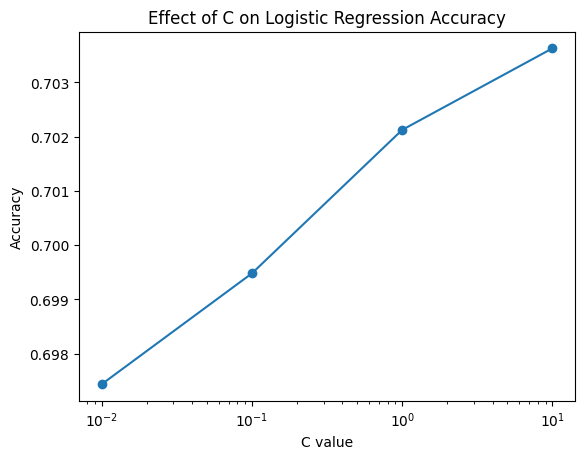

In [150]:
plt.plot(C_values, scores, marker='o')
plt.title("Effect of C on Logistic Regression Accuracy")
plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.xscale("log")
plt.show()

In [151]:
trees = [100, 300, 500]
scores = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, max_depth=12, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

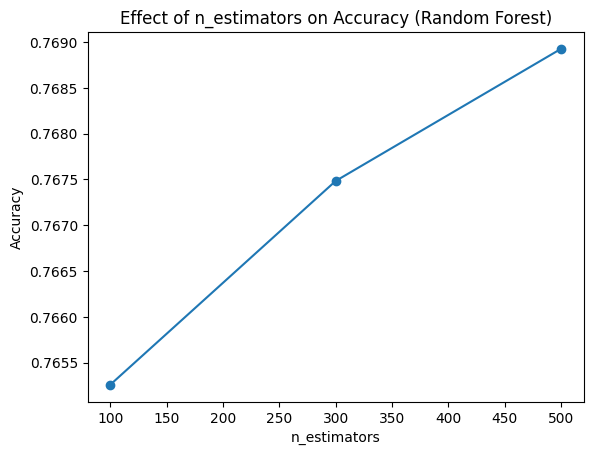

In [152]:
plt.plot(trees, scores, marker='o')
plt.title("Effect of n_estimators on Accuracy (Random Forest)")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

## Evalution 

In [153]:

acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic WITHOUT PCA:", acc_log)


acc_log_pca = accuracy_score(y_test_pca, y_pred_log_pca)
print("Logistic WITH PCA:", acc_log_pca)


acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest WITHOUT PCA:", acc_rf)

acc_rf_pca = accuracy_score(y_test_pca, y_pred_rf_pca)
print("Random Forest WITH PCA:", acc_rf_pca)

Logistic WITHOUT PCA: 0.7021225422403945
Logistic WITH PCA: 0.637784859599543
Random Forest WITHOUT PCA: 0.7689255005712224
Random Forest WITH PCA: 0.720161144849979


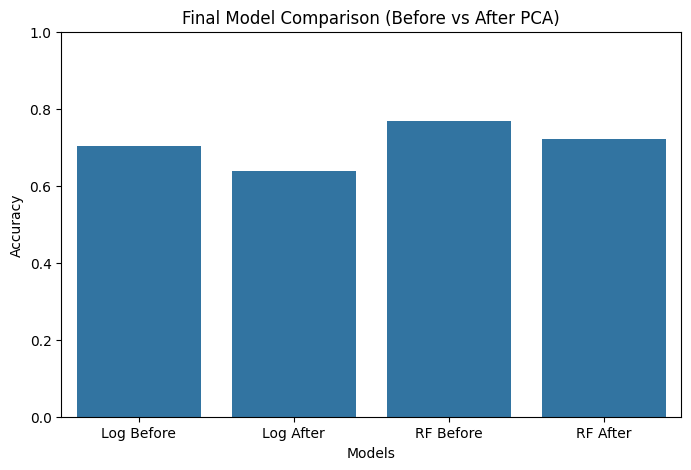

In [154]:
models = ['Log Before', 'Log After', 'RF Before', 'RF After']
scores = [acc_log, acc_log_pca, acc_rf, acc_rf_pca]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=scores)

plt.ylim(0,1)
plt.title("Final Model Comparison (Before vs After PCA)")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

In [155]:
import joblib

joblib.dump(rf_model, "model.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']